### Import

In [15]:
import utils as ut

### Parameters

In [16]:
target_column = "AMZN"
input_days= 30
output_days= [1, 7, 14]
test_size=0.2
shuffle=True

### Load dataset

In [17]:
data = ut.read_and_clean_data(file_path = "./dataset/portfolio_data.csv", drop_list = ["DPZ", "BTC", "NFLX"])

Loading the data...
Data shape: (1520, 2)
Null values: Date    0
AMZN    0
dtype: int64
Duplicate rows: 0
Converting Date column to datetime...
Load data completed.


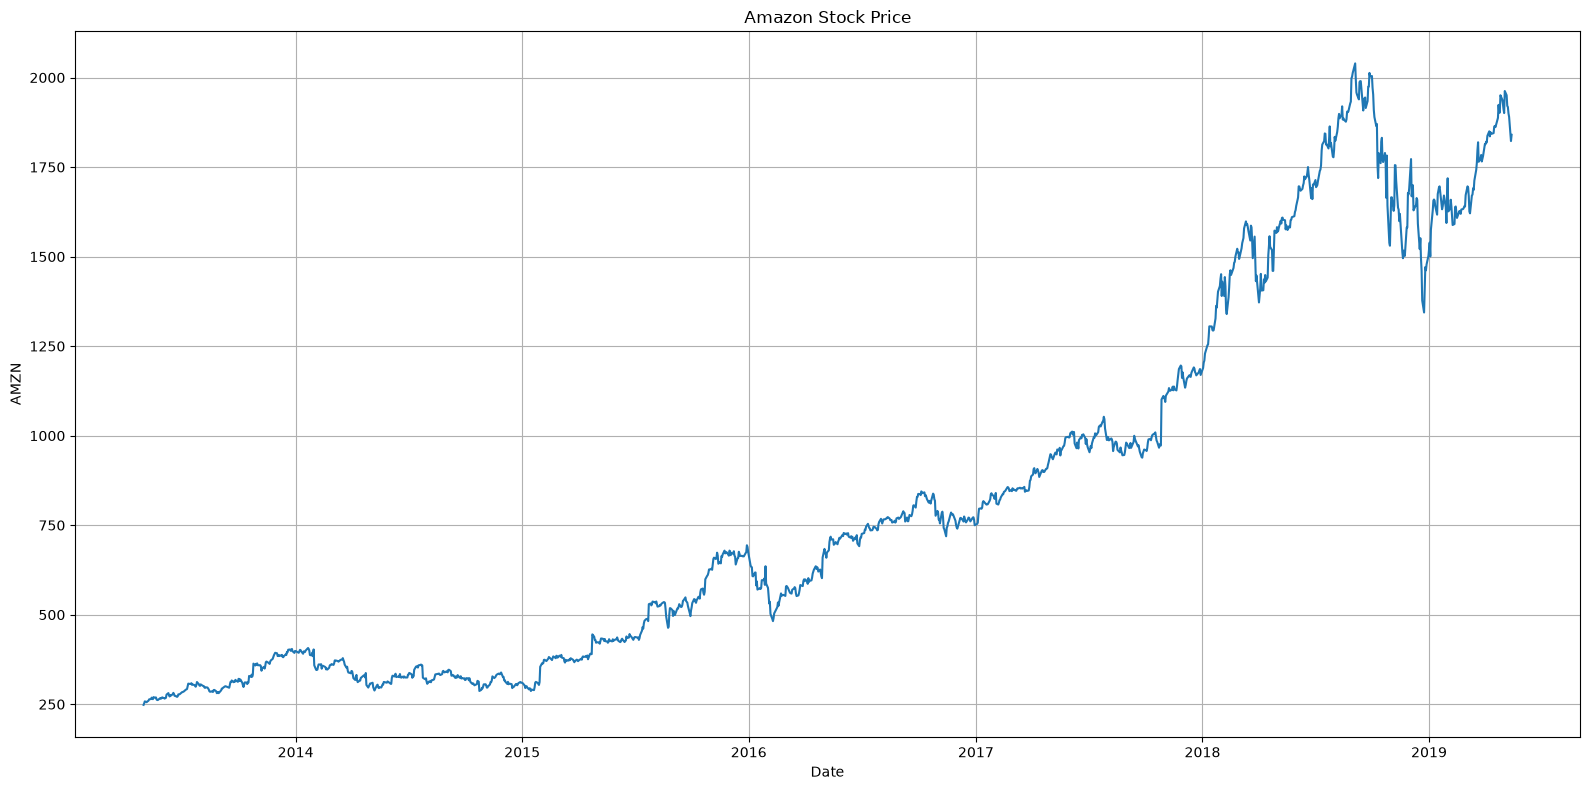

In [18]:
ut.plot_data(data, "Amazon Stock Price", "Date", "AMZN")

### Generate Sliding Windows

In [19]:
selected_value = data[target_column].values
window_data = {}
for days in output_days:
    X, y = ut.generate_sliding_windows(
        selected_value,
        input_days,
        days
        )
    window_data[days] = {
        "X" : X,
        "y" : y
    }

Input : 30 days | Output : 1 days | Windows: 1490
Input : 30 days | Output : 7 days | Windows: 1484
Input : 30 days | Output : 14 days | Windows: 1477


### Split Data

In [20]:
train_test_data = ut.split_data(
    window_data,
    output_days,
    test_size,
    shuffle
)

### Data Scaling

In [21]:
scaled_data = ut.scale_all_data(train_test_data)

### Train Regression Models

### Dense Deep Network

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [23]:
def generate_model():
    dense_model = Sequential()
    dense_model.add(Dense(8, input_shape = (30,), activation= "relu"))
    dense_model.add(Dense(19, activation= "relu"))
    dense_model.add(Dense(66, activation= "relu"))
    dense_model.add(Dense(101, activation= "relu"))
    dense_model.add(Dense(47, activation= "relu"))
    dense_model.add(Dense(11, activation= "relu"))
    dense_model.add(Dense(1))
    dense_model.summary()

    return dense_model

In [24]:
dense_model = generate_model()

e:\Python Git\ML\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 8)              │           248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 19)             │           171 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 66)             │         1,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 101)            │         6,767 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 47)             │         4,794 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 11)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,840 (54.06 KB)

 Trainable params: 13,840 (54.06 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Parameter formol = (input * neorons) + nouron

In [26]:
from tensorflow.keras.optimizers import Adam

dense_model1 = generate_model()
dense_model2 = generate_model()
dense_model3 = generate_model()

dense_model1.compile(
    loss='mean_squared_error',
    optimizer=Adam(learning_rate = 0.001),
    metrics=["mean_absolute_error","mean_squared_error","root_mean_squared_error"]
    )
dense_model2.compile(
    loss='mean_squared_error',
    optimizer=Adam(learning_rate = 0.001),
    metrics=["mean_absolute_error","mean_squared_error","root_mean_squared_error"]
    )
dense_model3.compile(
    loss='mean_squared_error',
    optimizer=Adam(learning_rate = 0.001),
    metrics=["mean_absolute_error","mean_squared_error","root_mean_squared_error"]
    )

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_35 (Dense)                │ (None, 8)              │           248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 19)             │           171 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 66)             │         1,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 101)            │         6,767 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 47)             │         4,794 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 11)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,840 (54.06 KB)

 Trainable params: 13,840 (54.06 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_49 (Dense)                │ (None, 8)              │           248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 19)             │           171 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 66)             │         1,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 101)            │         6,767 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 47)             │         4,794 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 11)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,840 (54.06 KB)

 Trainable params: 13,840 (54.06 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
history1 = dense_model1.fit(
    scaled_data[1]["X_train_norm"],
    scaled_data[1]["y_train_norm"], 
    epochs=1000,
    validation_data=(
    scaled_data[1]["X_test_norm"],
    scaled_data[1]["y_test_norm"]
    ),
    verbose=1,
    batch_size=500
)

Epoch 1/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 151ms/step - loss: 0.1857 - mean_absolute_error: 0.3165 - mean_squared_error: 0.1857 - root_mean_squared_error: 0.4309 - val_loss: 0.1556 - val_mean_absolute_error: 0.2741 - val_mean_squared_error: 0.1556 - val_root_mean_squared_error: 0.3945
Epoch 2/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.1547 - mean_absolute_error: 0.2818 - mean_squared_error: 0.1547 - root_mean_squared_error: 0.3933 - val_loss: 0.1288 - val_mean_absolute_error: 0.2451 - val_mean_squared_error: 0.1288 - val_root_mean_squared_error: 0.3588
Epoch 3/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.1261 - mean_absolute_error: 0.2515 - mean_squared_error: 0.1261 - root_mean_squared_error: 0.3552 - val_loss: 0.0987 - val_mean_absolute_error: 0.2153 - val_mean_squared_error: 0.0987 - val_root_mean_squared_error: 0.3141
Epoch 4/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0945 - mean_absolute_error: 0.2191 - mean_squared_error: 0.0945 - root_mean_squared_error

In [28]:
history2 = dense_model2.fit(
    scaled_data[7]["X_train_norm"],
    scaled_data[7]["y_train_norm"], 
    epochs=1000,
    validation_data=(
    scaled_data[7]["X_test_norm"],
    scaled_data[7]["y_test_norm"]
    ),
    verbose=1,
    batch_size=800
)

Epoch 1/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 286ms/step - loss: 0.0982 - mean_absolute_error: 0.2266 - mean_squared_error: 0.0982 - root_mean_squared_error: 0.3134 - val_loss: 0.0628 - val_mean_absolute_error: 0.1862 - val_mean_squared_error: 0.0628 - val_root_mean_squared_error: 0.2505
Epoch 2/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.0555 - mean_absolute_error: 0.1658 - mean_squared_error: 0.0555 - root_mean_squared_error: 0.2356 - val_loss: 0.0256 - val_mean_absolute_error: 0.1161 - val_mean_squared_error: 0.0256 - val_root_mean_squared_error: 0.1601
Epoch 3/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0210 - mean_absolute_error: 0.1002 - mean_squared_error: 0.0210 - root_mean_squared_error: 0.1450 - val_loss: 0.0034 - val_mean_absolute_error: 0.0439 - val_mean_squared_error: 0.0034 - val_root_mean_squared_error: 0.0586
Epoch 4/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0032 - mean_absolute_error: 0.0429 - mean_squared_error: 0.0032 - root_mean_squared_error

In [29]:
history3 = dense_model3.fit(
    scaled_data[14]["X_train_norm"],
    scaled_data[14]["y_train_norm"], 
    epochs=1000,
    validation_data=(
    scaled_data[14]["X_test_norm"],
    scaled_data[14]["y_test_norm"]
    ),
    verbose=1,
    batch_size=1000
)

Epoch 1/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 308ms/step - loss: 0.2877 - mean_absolute_error: 0.3927 - mean_squared_error: 0.2877 - root_mean_squared_error: 0.5363 - val_loss: 0.1518 - val_mean_absolute_error: 0.2796 - val_mean_squared_error: 0.1518 - val_root_mean_squared_error: 0.3896
Epoch 2/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.1468 - mean_absolute_error: 0.2721 - mean_squared_error: 0.1468 - root_mean_squared_error: 0.3831 - val_loss: 0.0793 - val_mean_absolute_error: 0.1992 - val_mean_squared_error: 0.0793 - val_root_mean_squared_error: 0.2816
Epoch 3/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.0773 - mean_absolute_error: 0.1947 - mean_squared_error: 0.0773 - root_mean_squared_error: 0.2780 - val_loss: 0.0374 - val_mean_absolute_error: 0.1346 - val_mean_squared_error: 0.0374 - val_root_mean_squared_error: 0.1934
Epoch 4/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.0367 - mean_absolute_error: 0.1315 - mean_squared_error: 0.0367 - root_mean_squared_error

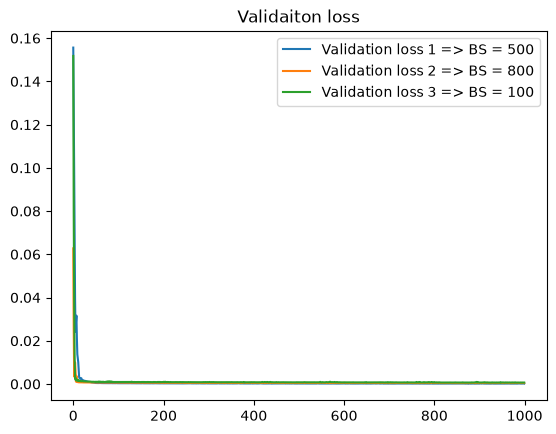

In [30]:
import matplotlib.pyplot as plt

plt.plot(history1.history['val_loss'], label='Validation loss 1 => BS = 500')
plt.plot(history2.history['val_loss'], label='Validation loss 2 => BS = 800')
plt.plot(history3.history['val_loss'], label='Validation loss 3 => BS = 100')
plt.title('Validaiton loss')
plt.legend()
plt.show()